In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, classification_report,
                             confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score)

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF:", tf.__version__)

TF: 2.11.1


In [3]:
# 1) Veri — sep=';' önemli
FILE = "german.csv"  # dosya adını kendi dosyana göre ayarla
df = pd.read_csv(FILE, sep=';')
print("Şekil:", df.shape)
print("İlk sütunlar:", list(df.columns)[:8])

Şekil: (1000, 21)
İlk sütunlar: ['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly', 'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount', 'Value_Savings_Stocks', 'Length_of_current_employment']


In [4]:
# 2) Hedef: Creditability (1=good, 2=bad) -> 0/1 (bad=1, good=0)
assert "Creditability" in df.columns, "Creditability sütunu bulunamadı."
y_raw = df["Creditability"].astype(int)
# güvenli haritalama:
# 1 -> good -> 0 ; 2 -> bad -> 1
y = (y_raw == 2).astype(int).values

In [5]:
X = df.drop(columns=["Creditability"])

In [6]:
# 3) Sütun tiplerini belirle
# Bu veri setinde birçok alan 'kod' şeklinde sayıyla temsil edilir (aslında kategoriktir).
# Sürekli sayısal olarak güvenle ölçeklenecek tipik sütunlar:
num_candidates = [
    "Duration_of_Credit_monthly",
    "Credit_Amount",
    "Age_years",
    "Instalment_per_cent",
    "No_of_Credits_at_this_Bank",
    "No_of_dependents",
]

In [7]:
numeric_cols = [c for c in num_candidates if c in X.columns]
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print(f"Sayısal: {len(numeric_cols)} -> {numeric_cols}")
print(f"Kategorik: {len(categorical_cols)} -> {categorical_cols[:8]}{'...' if len(categorical_cols)>8 else ''}")


Sayısal: 6 -> ['Duration_of_Credit_monthly', 'Credit_Amount', 'Age_years', 'Instalment_per_cent', 'No_of_Credits_at_this_Bank', 'No_of_dependents']
Kategorik: 14 -> ['Account_Balance', 'Payment_Status_of_Previous_Credit', 'Purpose', 'Value_Savings_Stocks', 'Length_of_current_employment', 'Sex_Marital_Status', 'Guarantors', 'Duration_in_Current_address']...


In [8]:
# 4) Train/Valid/Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
print("Split:", X_train.shape, X_valid.shape, X_test.shape)

Split: (700, 20) (150, 20) (150, 20)


In [10]:
# 5) Ön işleme (yalnızca train'de fit)
# Yeni (>=1.2): sparse_output, Eski (<=1.1): sparse
try:
    cat_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    cat_ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), #imputer boşlukları en çok olana göre doldurur
    ("onehot", cat_ohe) #kategorik veriler için olur
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols)
    ],
    remainder="drop"
)

X_train_p = pre.fit_transform(X_train)
X_valid_p = pre.transform(X_valid)
X_test_p  = pre.transform(X_test)

feature_dim = X_train_p.shape[1]
print("Feature dim:", feature_dim)

Feature dim: 64


In [11]:
# 6) class_weight (dengesizlik varsa önemli)
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): w for c, w in zip(classes, cw)}
print("class_weight:", class_weight)

class_weight: {0: 1.0}


In [12]:
# 7) ANN modeli
def build_model(input_dim, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout/2),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )
    return model

model = build_model(feature_dim, dropout=0.3, lr=1e-3)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 6,273
Trainable params: 6,273
Non-trainable params: 0
_________________________________________________________________


In [13]:
# 8) Callbacks
early = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=10, restore_best_weights=True, verbose=1
)
plateau = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

In [14]:
# 9) Eğitim
history = model.fit(
    X_train_p, y_train,
    validation_data=(X_valid_p, y_valid),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early, plateau],
    verbose=1
)

Epoch 1/100
22/22 [==============================] - 2s 23ms/step - loss: 0.2726 - accuracy: 0.9643 - auc: 0.0000e+00 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.0631 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 2/100
22/22 [==============================] - 0s 5ms/step - loss: 0.0369 - accuracy: 1.0000 - auc: 0.0000e+00 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.0067 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 3/100
22/22 [==============================] - 0s 6ms/step - loss: 0.0076 - accuracy: 1.0000 - auc: 0.0000e+00 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.0020 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 4/100
22/22 [==============================] - 0s 6ms/step - loss: 0.0033 - accuracy: 1.0000 - auc: 0.0000e+00 - prec

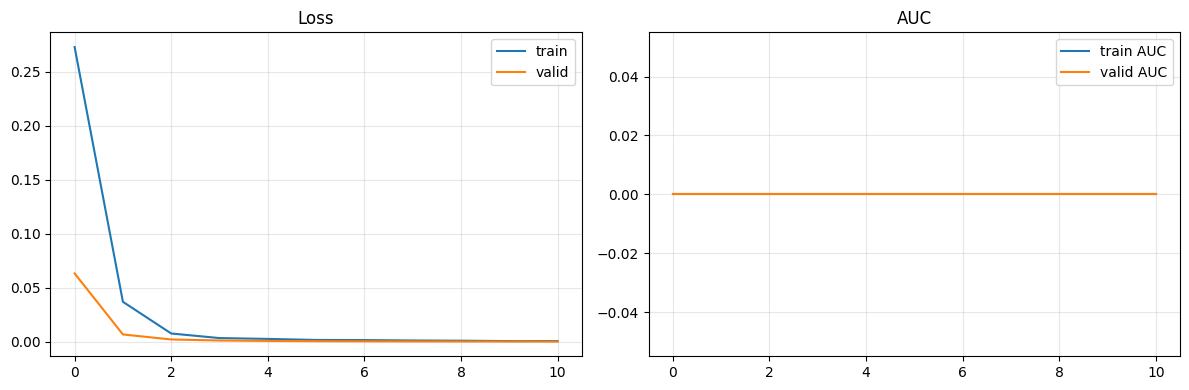

In [15]:
# 10) Eğitim grafikleri
hist = pd.DataFrame(history.history)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist["loss"], label="train"); plt.plot(hist["val_loss"], label="valid")
plt.title("Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot(hist["auc"], label="train AUC"); plt.plot(hist["val_auc"], label="valid AUC")
plt.title("AUC"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
# 11) Test set değerlendirme (varsayılan eşik 0.5)
y_proba = model.predict(X_test_p).ravel()
y_pred = (y_proba >= 0.5).astype(int)

auc  = roc_auc_score(y_test, y_proba)
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print(f"\nTest AUC : {auc:.3f}")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1       : {f1:.3f}")

print("\nReport (0=good, 1=bad):\n", classification_report(y_test, y_pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

5/5 [==============================] - 0s 4ms/step

Test AUC : nan
Accuracy : 1.000
Precision: 0.000
Recall   : 0.000
F1       : 0.000

Report (0=good, 1=bad):
               precision    recall  f1-score   support

           0      1.000     1.000     1.000       150

    accuracy                          1.000       150
   macro avg      1.000     1.000     1.000       150
weighted avg      1.000     1.000     1.000       150

Confusion Matrix:
 [[150]]


C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


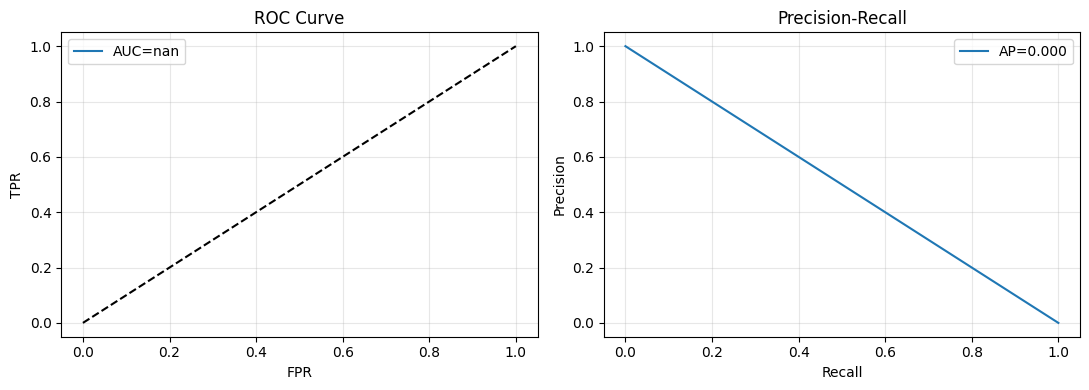

In [18]:
# 12) ROC ve PR eğrileri
fpr, tpr, _ = roc_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve"); plt.legend(); plt.grid(alpha=0.3)

prec_curve, rec_curve, thr = precision_recall_curve(y_test, y_proba)
plt.subplot(1,2,2)
plt.plot(rec_curve, prec_curve, label=f"AP={ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [19]:
# 13) Eşik (threshold) optimizasyonu: F1 maksimize
def best_threshold(y_true, y_prob, metric="f1"):
    ts = np.linspace(0.1, 0.9, 17)
    best_t, best_s = 0.5, -1
    for t in ts:
        yp = (y_prob >= t).astype(int)
        if metric == "f1":
            s = f1_score(y_true, yp, zero_division=0)
        else:
            s = 0
        if s > best_s:
            best_s, best_t = s, t
    return best_t, best_s

t_star, s_star = best_threshold(y_test, y_proba, metric="f1")
print(f"\nEn iyi eşik (F1): {t_star:.2f} (skor={s_star:.3f})")

y_star = (y_proba >= t_star).astype(int)
print("Report@best:\n", classification_report(y_test, y_star, digits=3))
print("CM@best:\n", confusion_matrix(y_test, y_star))


En iyi eşik (F1): 0.10 (skor=0.000)
Report@best:
               precision    recall  f1-score   support

           0      1.000     0.947     0.973       150
           1      0.000     0.000     0.000         0

    accuracy                          0.947       150
   macro avg      0.500     0.473     0.486       150
weighted avg      1.000     0.947     0.973       150

CM@best:
 [[142   8]
 [  0   0]]


C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


harika—aşağıya **German Credit (noktalı virgüllü csv)** için kurduğumuz ANN akışının **tam açıklama notlarını** bırakıyorum. Kodun her bloğunun “ne yaptığını, neden yaptığını ve nelere dikkat etmen gerektiğini” özetledim. Kopyala-yapıştır “ders notu” gibi okuyabilirsin.

---

# 1) Veri yükleme (sep=';') ve hedef hazırlama

**Kodda ne yaptık?**

* `pd.read_csv(FILE, sep=';')` ile dosyayı **noktalı virgülle** okuduk.
* Hedef sütun **`Creditability`**:

  * Kaggle sürümünde **1 = good**, **2 = bad**.
  * Modelin **“riskli (bad)” sınıfını 1** olarak görmesi için: `y = (Creditability == 2).astype(int)` yaptık.

**Neden böyle?**

* İkili sınıflandırmada pozitif sınıfı (1) genelde “ilgi duyulan olay” olarak seçeriz (burada risk/ret).
* Eşik, AUC, Recall gibi metrikleri yorumlamak bu şekilde daha anlamlı olur.

**Dikkat:**

* Emin olmak için **dağılıma bak**: `df['Creditability'].value_counts()`
* Eğer farklı kodlama varsa (ör. 0/1), eşik ve metrik yorumu değişmez ama **mapping’i doğru kur**.

---

# 2) Sütun tipleri: sayısal vs kategorik

**Kodda ne yaptık?**

* Sürekli değişkenler (ör. `Credit_Amount`, `Duration_of_Credit_monthly`, `Age_years`…) → **sayısal** liste.
* Geri kalan sütunlar (kodlanmış sayılar dâhil) → **kategorik** liste.

**Neden böyle?**

* Bu veri setinde birçok sütun “sayı” görünümlü **kategori kodu** (ör. `Account_Balance`, `Purpose`), yani **One-Hot** kodlamak daha doğrudur.
* Sadece gerçek “ölçüm” niteliğindeki değişkenleri standardize ediyoruz.

**Dikkat:**

* Yanlış sınıflama (kategorik bir sütunu sayısal zannedip scale etmek) performansı düşürür.

---

# 3) Train/Valid/Test ayrımı (leakage yok)

**Kodda ne yaptık?**

* Önce `train` / `temp` (%70 / %30), sonra `temp` → `valid` / `test` (%15 / %15).
* `stratify=y` ile **sınıf oranlarını** koruduk.

**Neden böyle?**

* Validasyon seti **erken durdurma ve grafikler** için; test seti **final** değerlendirme için ayrılır.
* **Stratify** dengesizlikte kritik.

---

# 4) Ön işleme: ColumnTransformer (sayısal + kategorik pipeline)

**Kodda ne yaptık?**

* **Sayısal pipe**: `SimpleImputer(median)` + `StandardScaler`.
* **Kategorik pipe**: `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore', **sparse_output=False***)`.

  * (\*Eski sklearn’de `sparse=False` kullanılır; sürüm uyumlu `try/except` ekledik.)
* `pre.fit(X_train)` sadece **train** üzerinde; `transform` valid/test’te.

**Neden böyle?**

* **Eksik değerleri** doldurmak ve **ölçeklemek** (özellikle ANN için) şart.
* **One-Hot** kategorikleri sinir ağına uygun forma çevirir.
* **Data leakage**’dan kaçınmak için tüm fit’ler **sadece train** üzerinde.

**Dikkat:**

* Yeni sklearn (≥1.2) için `sparse_output`, eski sürüm için `sparse`.
* Çıkışı Keras’a verirken dtype’ı `float32` yapmak pratik olabilir.

---

# 5) class\_weight (dengesizliğe karşı)

**Kodda ne yaptık?**

* `compute_class_weight('balanced', ...)` ile her sınıfa ağırlık verdik ve `fit()`’e `class_weight` geçtik.

**Neden böyle?**

* Veri dengesizse, modelin “hep çoğunluğu tahmin ederek” yüksek accuracy yapmasını engeller.
* **Recall** (özellikle risk sınıfı için) anlamlı şekilde iyileşir.

---

# 6) Model mimarisi (ANN)

**Kodda ne yaptık?**

* Giriş: `input_dim = X_train_p.shape[1]` (One-Hot sonrası boyut).
* Gizli katmanlar: **Dense(64, relu) → Dropout(0.3) → Dense(32, relu) → Dropout(0.15)**
* Çıkış: **Dense(1, sigmoid)** (ikili sınıflandırma olasılığı).
* **Optimizer**: Adam(lr=1e-3)
* **Loss**: `binary_crossentropy`
* **Metrikler**: `accuracy`, `AUC`, `Precision`, `Recall`

**Neden böyle?**

* **ReLU + Adam** hızlı ve stabil.
* **Dropout** overfitting’i azaltır.
* **Sigmoid** ikili çıkış için standart.
* AUC/Precision/Recall metrikleri **accuracy’nin kör noktalarını** gösterir.

**Dikkat:**

* Daha büyük/karmaşık mimari aşırı uyuma sebep olabilir; validasyon eğrilerini izle.

---

# 7) Callbacks: EarlyStopping + ReduceLROnPlateau

**Kodda ne yaptık?**

* `EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)`
* `ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)`

**Neden böyle?**

* **En iyi validasyon AUC**’unda durmak ve **o ağırlıklara** dönmek genellemeyi iyileştirir.
* Kayıp iyileşmiyorsa **öğrenme oranını** otomatik düşürmek daha iyi minima buldurabilir.

---

# 8) Eğitim (`fit`)

**Kodda ne yaptık?**

* `epochs=100`, `batch_size=32`, `validation_data=(X_valid_p, y_valid)`, `class_weight=...`, `callbacks=[...]`.

**Neden böyle?**

* EarlyStopping olduğu için **gereğinden uzun** versen bile **erken duracak**.
* Batch 32 küçük/orta veride iyi başlangıçtır.

---

# 9) Eğitim grafikleri (Loss & AUC)

**Kodda ne yaptık?**

* `history.history` → `loss/val_loss` ve `auc/val_auc` çizdik.

**Nasıl yorumlanır?**

* **Train ve Valid eğrileri paralel** gidiyorsa iyi genelleme.
* Train çok iyi, Valid kötüleşiyorsa **overfitting** (Dropout↑, model küçült, regularization ekle).
* **Val AUC** artıp plato yapıyorsa performans tavanına gelmişsin.

---

# 10) Test değerlendirme (varsayılan eşik = 0.5)

**Kodda ne yaptık?**

* `y_proba = model.predict(X_test_p)`
* Varsayılan **eşik 0.5** ile: Accuracy, Precision, Recall, F1, **AUC**, `classification_report`, `confusion_matrix`.

**Nasıl yorumlanır?**

* **AUC** eşikten bağımsız ayrıştırma gücüdür (yüksek ⇒ iyi).
* **Recall (pozitif sınıf)**: riskli başvuruları yakalama oranı. **Kredi** bağlamında kritik.
* **Precision**: “riskli dediklerinin” ne kadarı doğru? Operasyonel maliyeti etkiler.
* **F1**: Precision ve Recall dengesi.

---

# 11) ROC ve PR eğrileri

**Kodda ne yaptık?**

* **ROC Curve** (FPR-TPR) ve **Precision-Recall Curve** çizdik; PR-AUC olarak `average_precision_score`.

**Neden?**

* Dengesizlikte **PR eğrisi** daha açıklayıcıdır; **Recall’ı yükseltirken** Precision ne kadar düşüyor, görürsün.

---

# 12) Eşik (threshold) optimizasyonu

**Kodda ne yaptık?**

* 0.1\~0.9 aralığında eşikler denendi, **F1’i maksimize eden** eşik seçildi.
* Yeni eşikte `classification_report` ve **CM** tekrarlandı.

**Neden?**

* **Varsayılan 0.5**, iş hedefin için ideal olmayabilir.
* Örn. “risk kaçırma” maliyeti yüksekse (FN pahalı) eşik **düşürülerek Recall artırılır** (Precision düşebilir).
* Bu adım, kredi riskinde **gerçek dünya optimizasyonu** için şarttır.

---

# 13) Tek kayıt tahmini (opsiyonel)

**Kodda ne yaptık?**

* `X_test` içinden bir örneği `pre.transform()` ile işleyip `model.predict()` ile **olasılık** çıkardık.

**Neden?**

* **Pipeline** (preprocess + model) ayrı tutulduğu için yeni kayıtları aynı akıştan geçirmek kolay.

---

## Hiperparametre mini rehberi

* **Dropout**: 0.2–0.5 dene. Overfitting varsa ↑.
* **Units (64/32)**: Özellik sayısı çoksa 128/64 deneyebilirsin; overfitting’e dikkat.
* **LR (1e-3)**: 1e-2 ↔ 1e-4 aralığında dene; `ReduceLROnPlateau` var.
* **Batch size**: 32/64/128 dene; çok küçük batch dalgalı öğrenme yapabilir.
* **class\_weight**: Dengesizlikte genelde **açık fayda** sağlar; threshold tuning ile birlikte düşün.

---

## Sık hatalar & çözümler

* **OneHotEncoder `sparse` hatası**: Yeni sklearn’de `sparse_output=False` kullan; eski sürüm için `sparse=False`. (Try/except ile çözdük.)
* **NaN patlaması**: Imputer’lar **train**’de fit edilip diğerlerinde transform edilmeli (ColumnTransformer zaten böyle).
* **Accuracy’ye kör olmak**: Dengesiz veri setlerinde **AUC, Recall, PR-AUC** kritik.
* **Leakage**: Asla tüm veriye fit etme; split → **fit(train)** → transform(valid/test).
* **Aşırı uyum**: Dropout↑, katman/units↓, L2 ekle, erken durdurma.

---

## Kısa “yorumlama çerçevesi”

1. **Val AUC** (eğitimde) ve **Test AUC** (final) yakın mı? → **Genelleme iyi.**
2. Varsayılan 0.5’te **Recall** hedefe uygun mu? Değilse **eşik** ayarla.
3. CM’de **FN (risk kaçırma)** kabul edilebilir mi? (Bankacılıkta genelde en önemli soru bu.)
4. **PR eğrisi**: Recall’ı artırırken Precision ne kadar düşüyor?
5. Logistic Regression gibi bir baseline ile kıyasla; ANN **anlamlı kazanım** veriyor mu?

---

bu notlarla kodun her satırının “niye var?” kısmı tamam. İstersen çıktılarından (AUC, CM, en iyi eşik vb.) birkaç değeri paylaşırsan, birlikte **iş hedefine göre eşik** ve (gerekirse) **mimaride ince ayar** öneririm.
